11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 414s 877ms/step - loss: 0.1610 - val_loss: 0.0720
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 421s 832ms/step - loss: 0.0712 - val_loss: 0.0685
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 442s 833ms/step - loss: 0.0685 - val_loss: 0.0668
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 391s 834ms/step - loss: 0.0671 - val_loss: 0.0660
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 396s 845ms/step - loss: 0.0662 - val_loss: 0.0653
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 436s 832ms/step - loss: 0.0657 - val_loss: 0.0649
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 389s 830ms/step - loss: 0.0652 - val_loss: 0.0644
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 441s 827ms/step - loss: 0.0649 - val_loss: 0.0641
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 388s 828ms/step - loss: 0.0644 - val_loss: 0.0641
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 448s 839ms/step - loss: 0.0640 - val_loss: 0.0636
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
313/31

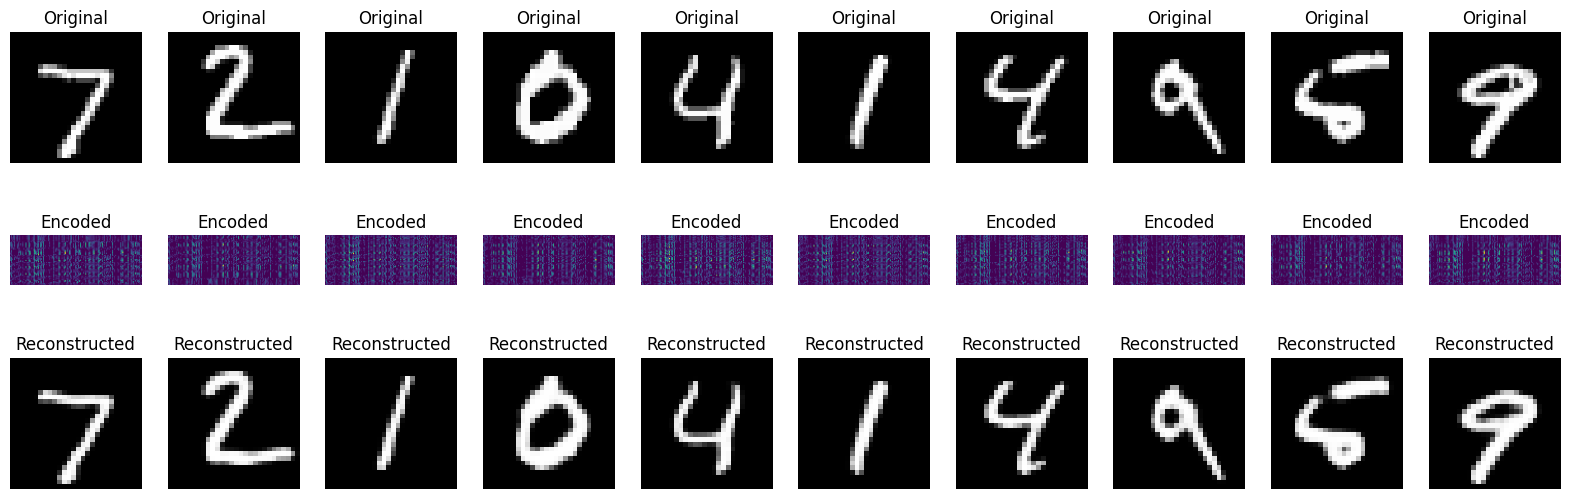

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Define the Autoencoder
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
encoded = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

# Decoder
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Build the Autoencoder model
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the Autoencoder
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, validation_data=(x_test, x_test))

# Encode and decode test samples
encoder = models.Model(input_img, encoded)
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

# Visualize input, encoded representation, and reconstructed output
def visualize_results(inputs, encoded, decoded, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Display original
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(inputs[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        # Display encoded
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(encoded[i].reshape(-1, encoded.shape[-1]), cmap='viridis')
        plt.title("Encoded")
        plt.axis("off")

        # Display reconstructed
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(decoded[i].reshape(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis("off")

    plt.show()

visualize_results(x_test, encoded_imgs, decoded_imgs)
